# 🏎️ Módulo 1 — Comparador de Voltas

Este notebook compara a telemetria de dois pilotos de F1 numa mesma 
sessão, usando dados reais via FastF1. Permite identificar onde um 
piloto ganha ou perde tempo ao longo da volta.

**Exemplo usado:** GP da Espanha 2025, Classificação — Piastri vs Norris

In [8]:
import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('cache', exist_ok=True)
fastf1.Cache.enable_cache('cache')

In [9]:
def comparar_pilotos(ano, gp, sessao, piloto1, piloto2):
    """
    Compara a telemetria de dois pilotos numa sessão específica.
    Plota velocidade, acelerador, marcha (3 painéis) e delta de tempo.
    """
    # Carrega a sessão
    session = fastf1.get_session(ano, gp, sessao)
    session.load()
    
    # Pega a volta mais rápida de cada piloto
    volta1 = session.laps.pick_driver(piloto1).pick_fastest()
    volta2 = session.laps.pick_driver(piloto2).pick_fastest()
    
    # Telemetria de cada um
    tel1 = volta1.get_telemetry().add_distance()
    tel2 = volta2.get_telemetry().add_distance()
    
    # --- Gráfico 1: velocidade, acelerador, marcha (3 painéis) ---
    fastf1.plotting.setup_mpl()
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    axes[0].plot(tel1['Distance'], tel1['Speed'], color='#FF8000', label=piloto1)
    axes[0].plot(tel2['Distance'], tel2['Speed'], color='#0090FF', label=piloto2, linestyle='--', alpha=0.8)
    axes[0].set_ylabel('Velocidade (km/h)')
    axes[0].legend()
    axes[0].grid(alpha=0.2)
    
    axes[1].plot(tel1['Distance'], tel1['Throttle'], color='#FF8000', label=piloto1)
    axes[1].plot(tel2['Distance'], tel2['Throttle'], color='#0090FF', label=piloto2, linestyle='--', alpha=0.8)
    axes[1].set_ylabel('Acelerador (%)')
    axes[1].legend()
    axes[1].grid(alpha=0.2)
    
    axes[2].plot(tel1['Distance'], tel1['nGear'], color='#FF8000', label=piloto1)
    axes[2].plot(tel2['Distance'], tel2['nGear'], color='#0090FF', label=piloto2, linestyle='--', alpha=0.8)
    axes[2].set_ylabel('Marcha')
    axes[2].set_xlabel('Distância (m)')
    axes[2].legend()
    axes[2].grid(alpha=0.2)
    
    fig.suptitle(f'{gp} {ano} {sessao} — {piloto1} vs {piloto2}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # --- Gráfico 2: delta de tempo ---
    tempo2_interp = np.interp(tel1['Distance'], tel2['Distance'], tel2['Time'].dt.total_seconds())
    tempo1 = tel1['Time'].dt.total_seconds()
    delta = tempo2_interp - tempo1
    
    plt.figure(figsize=(14, 4))
    plt.plot(tel1['Distance'], delta, color='purple')
    plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
    plt.xlabel('Distância (m)')
    plt.ylabel(f'Delta (s) — positivo = {piloto1} na frente')
    plt.title(f'{gp} {ano} {sessao} — Delta de tempo: {piloto1} vs {piloto2}')
    plt.grid(alpha=0.2)
    plt.show()
    
    return tel1, tel2

# visualização do FP3 do GP analisado

core           INFO 	Loading data for Spanish Grand Prix - Practice 3 [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '4'
core        WARNING 	Fixed incorrect tyre stint information for driver '31'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Fixed incorrect tyre stint information for driver '10'
core        WARNING 	Fixed incorrect tyre stint information for driver '43'
core        WARNING 	Fixed incorrect tyre stint information for driver '27'
core        WARNING 	Fixed incorrect tyre stint information for driver '18'
core        WARNING 	Fixed incorrect tyre stint information for driver '14'
core        WARNING 	Fixed incorrect tyre stint information for driver '55'
core        WARNING 	Dr

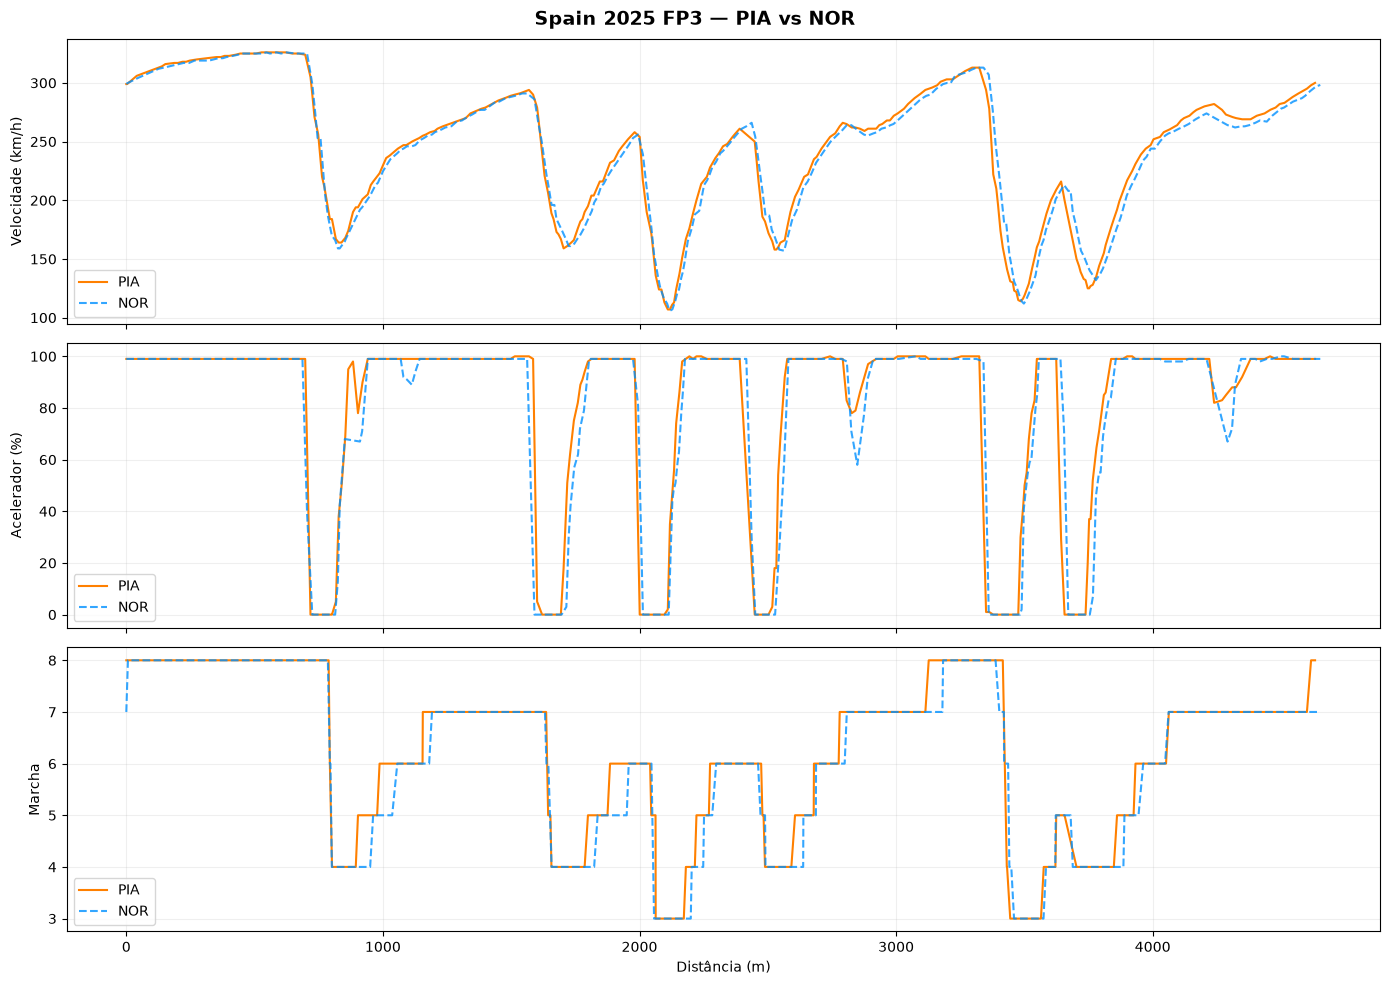

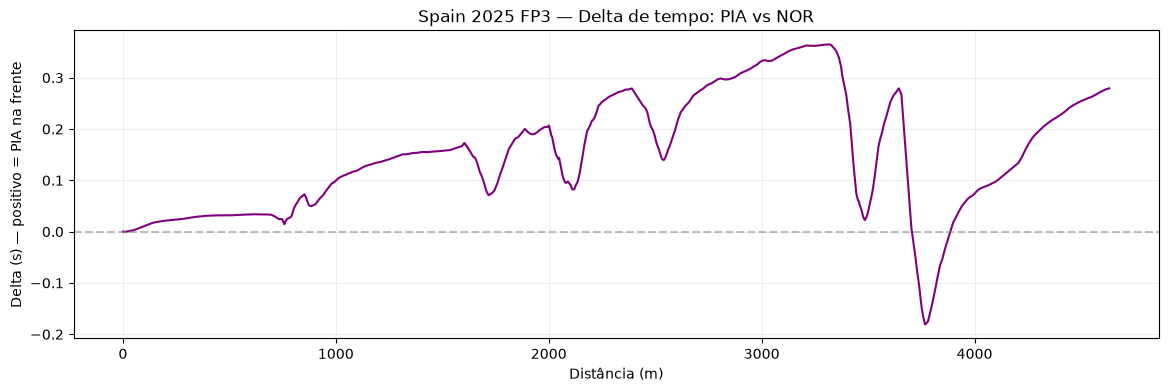

In [10]:
tel_pia, tel_nor = comparar_pilotos(2025, 'Spain', 'FP3', 'PIA', 'NOR')

# Visualização do FP2 do GP analisado

core           INFO 	Loading data for Spanish Grand Prix - Practice 2 [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '5', '6', '10', '12', '14', '16', '18', '22', '23', '27', '30', '31', '43', '44', '55', '63', '81', '87']
c:\Users\joaom\telemetria-f1\.venv\Lib\site-packages\fastf1\core.py:3175: FutureWarning: pick_driver is depre

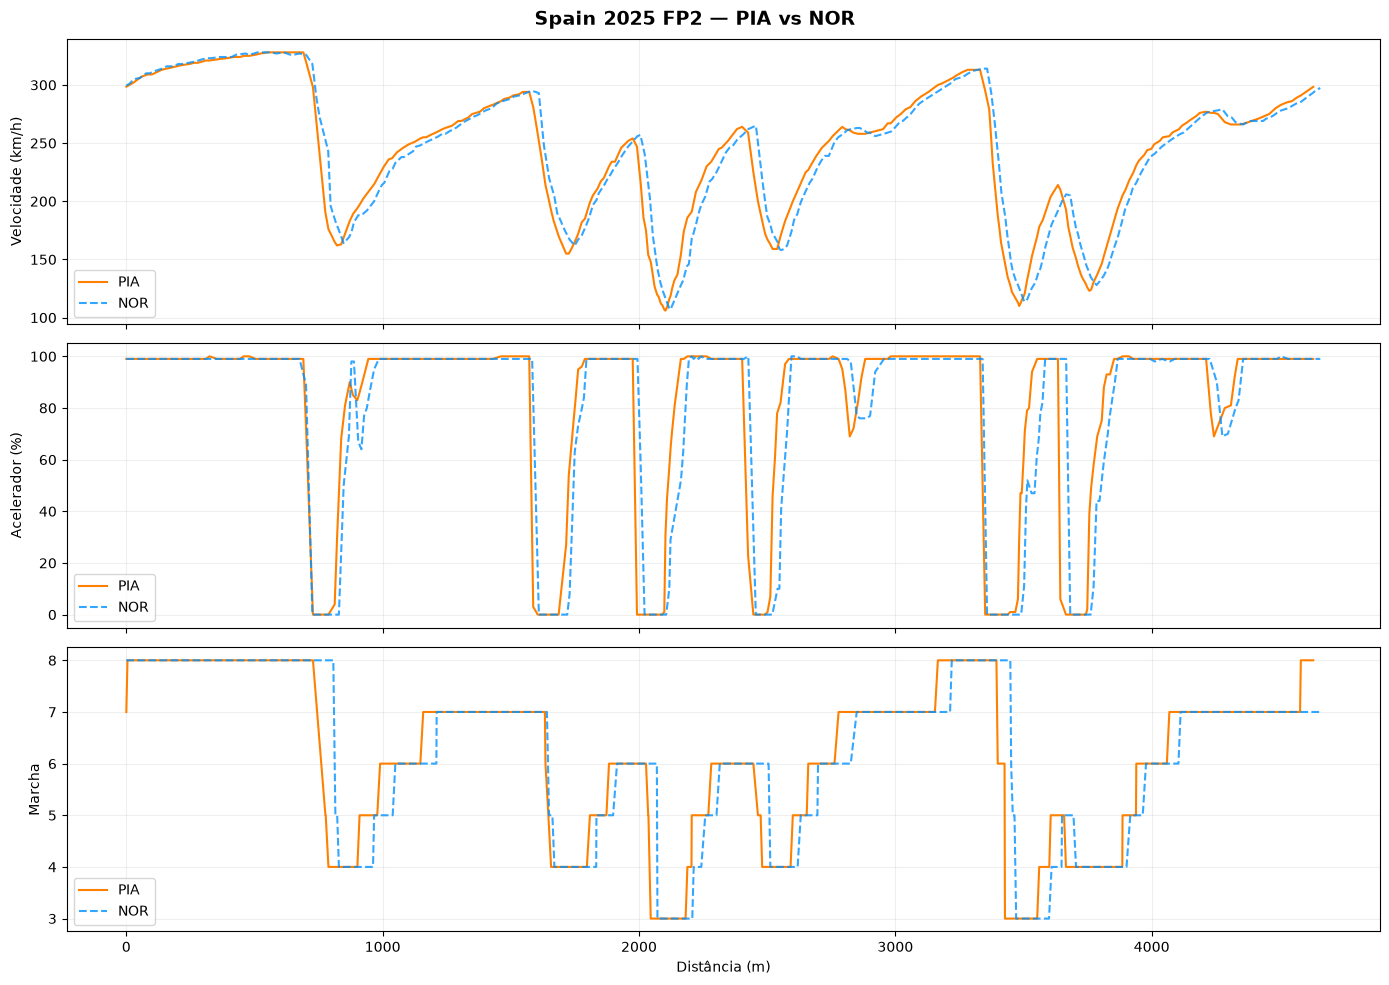

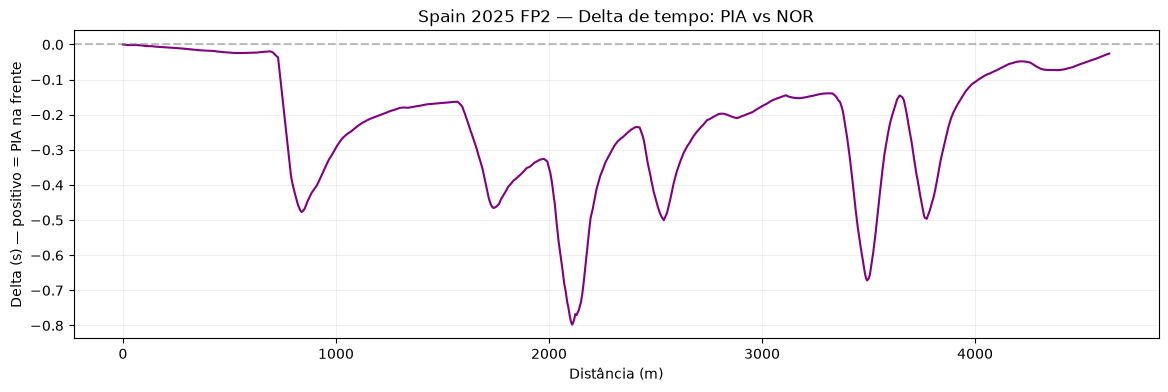

In [11]:
tel_pia, tel_nor = comparar_pilotos(2025, 'Spain', 'FP2', 'PIA', 'NOR')

# visualização do FP1 do GP analisado

core           INFO 	Loading data for Spanish Grand Prix - Practice 1 [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '5', '6', '10', '12', '14', '16', '18', '22', '27', '30', '43', '44', '45', '50', '55', '63', '81', '87']
c:\Users\joaom\telemetria-f1\.venv\Lib\site-packages\fastf1\core.py:3175: FutureWarning: pick_driver is depre

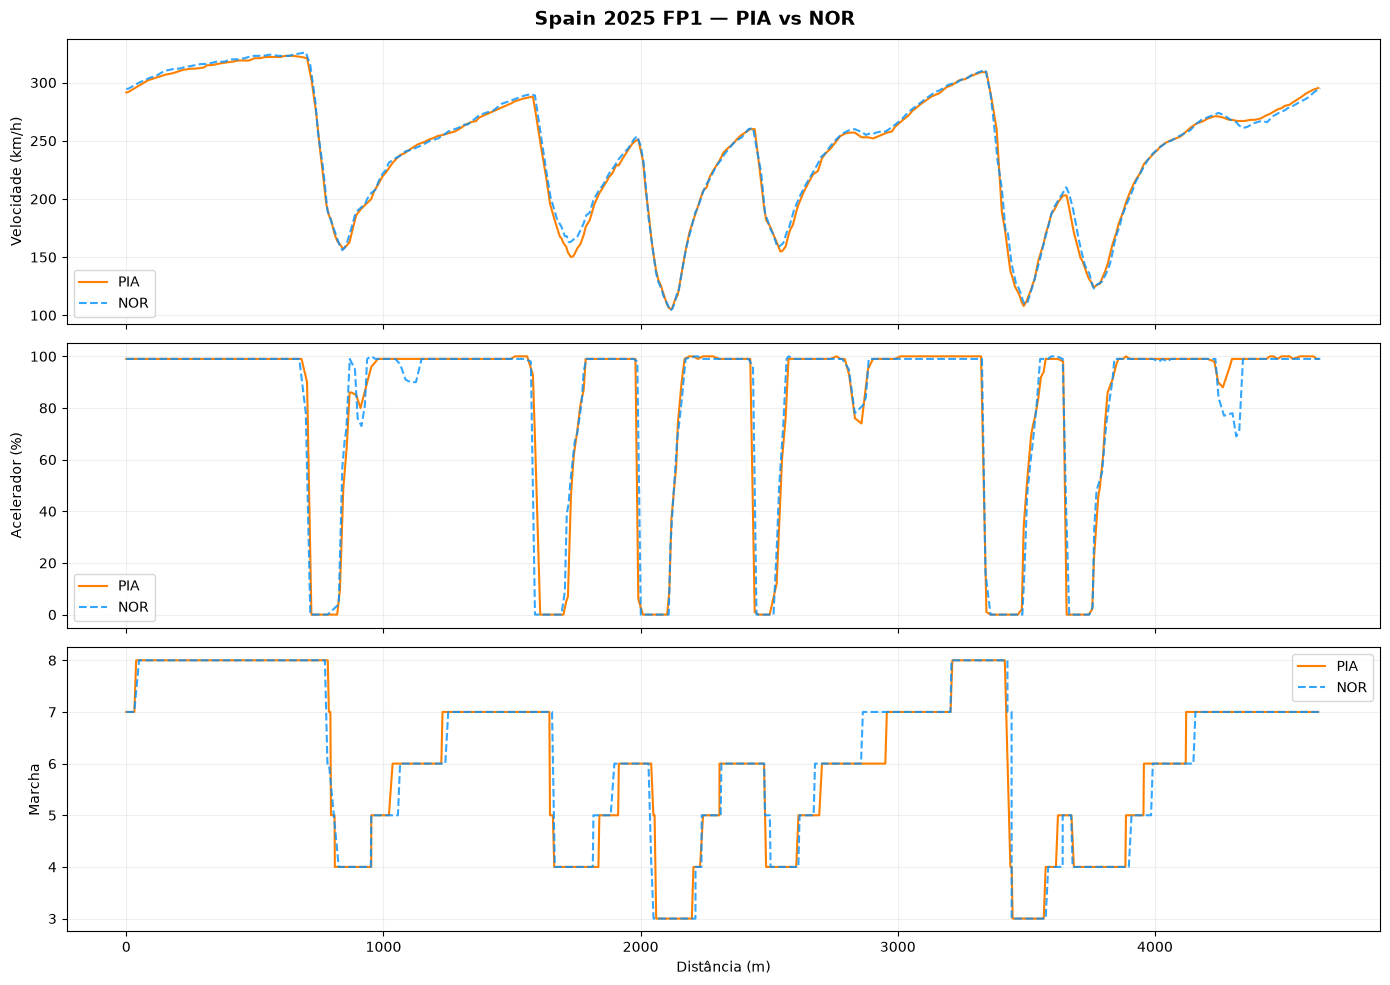

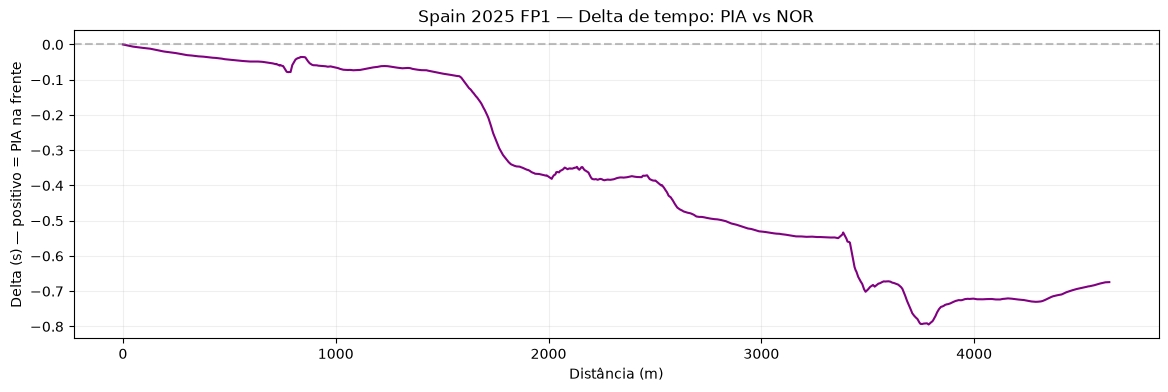

In [12]:
tel_pia, tel_nor = comparar_pilotos(2025, 'Spain', 'FP1', 'PIA', 'NOR')

# visualização do QUALY(melhor volta) do GP analisado

core           INFO 	Loading data for Spanish Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '1', '63', '44', '12', '16', '10', '6', '14', '23', '5', '30', '18', '87', '27', '31', '55', '43', '22']
c:\Users\joaom\telemetria-f1\.venv\Lib\site-packages\fastf1\core.py:3175: FutureWarning: pick_driver is depre

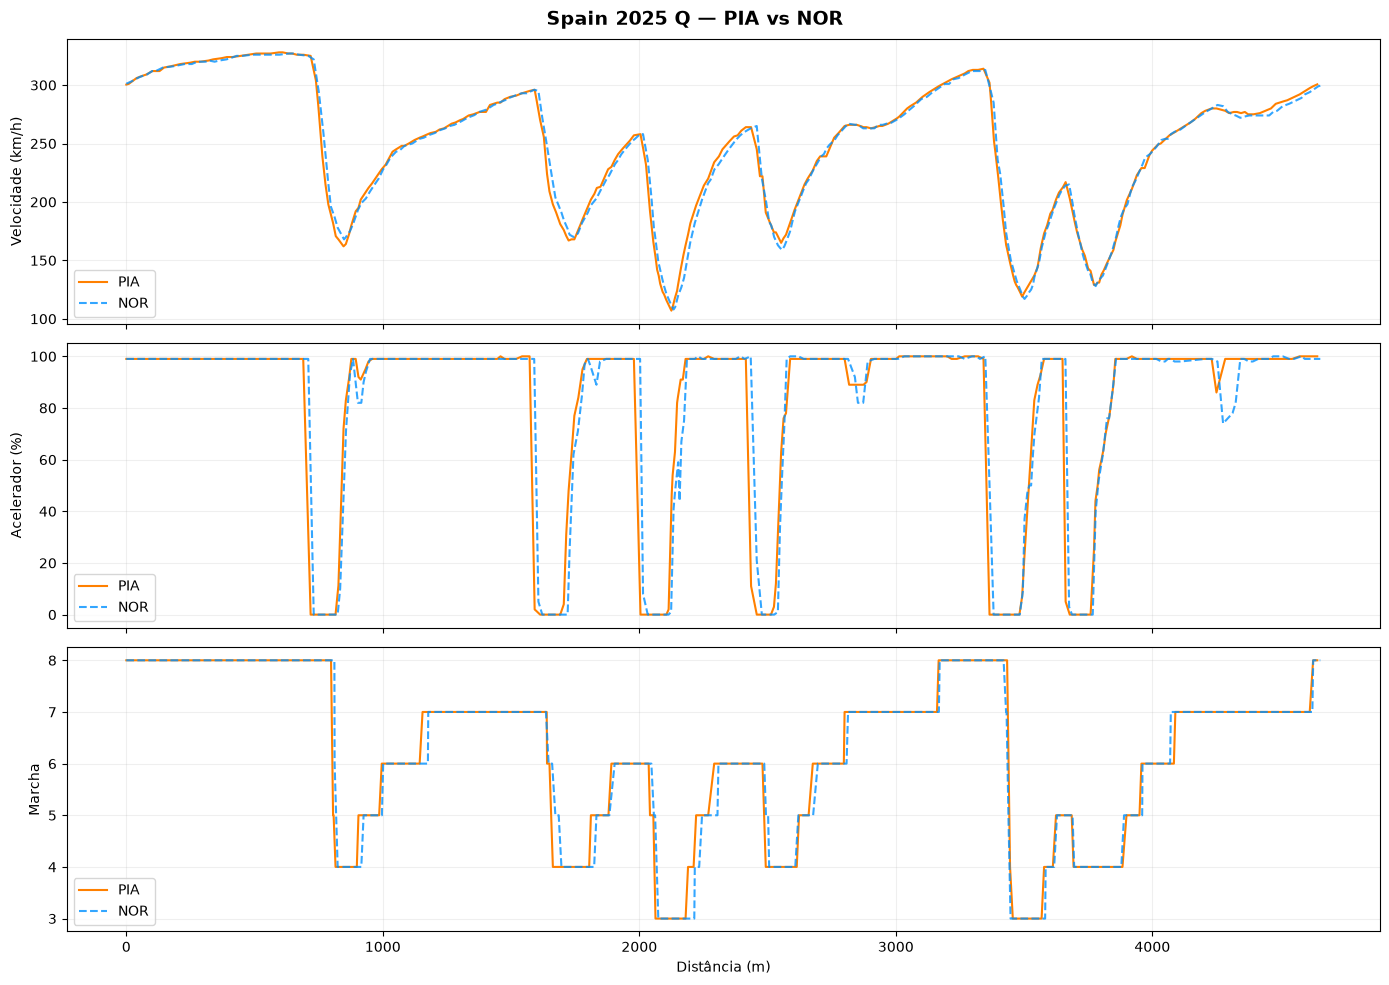

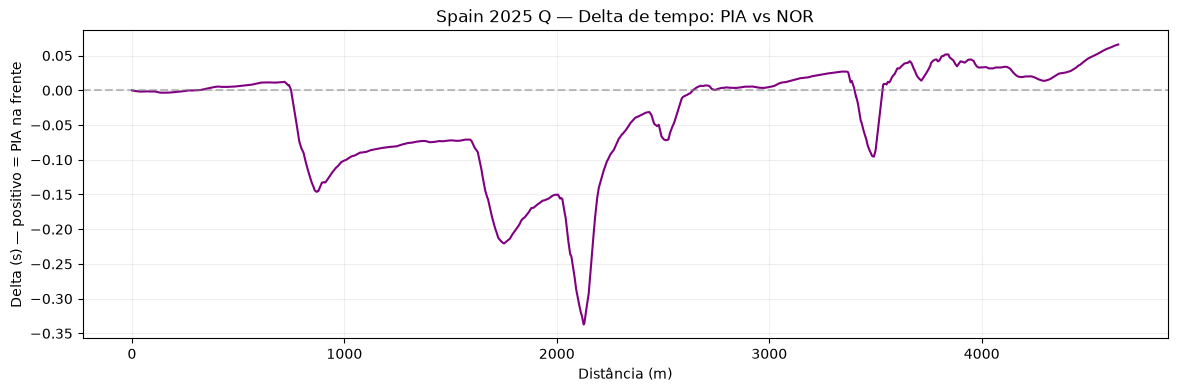

In [13]:
tel_pia, tel_nor = comparar_pilotos(2025, 'Spain', 'Q', 'PIA', 'NOR')

# visualização da corrida(melhor volta) do GP analisado

core           INFO 	Loading data for Spanish Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 19 drivers: ['81', '4', '16', '63', '27', '44', '6', '10', '14', '1', '30', '5', '22', '55', '43', '31', '87', '12', '23']
c:\Users\joaom\telemetria-f1\.venv\Lib\site-packages\fastf1\core.py:

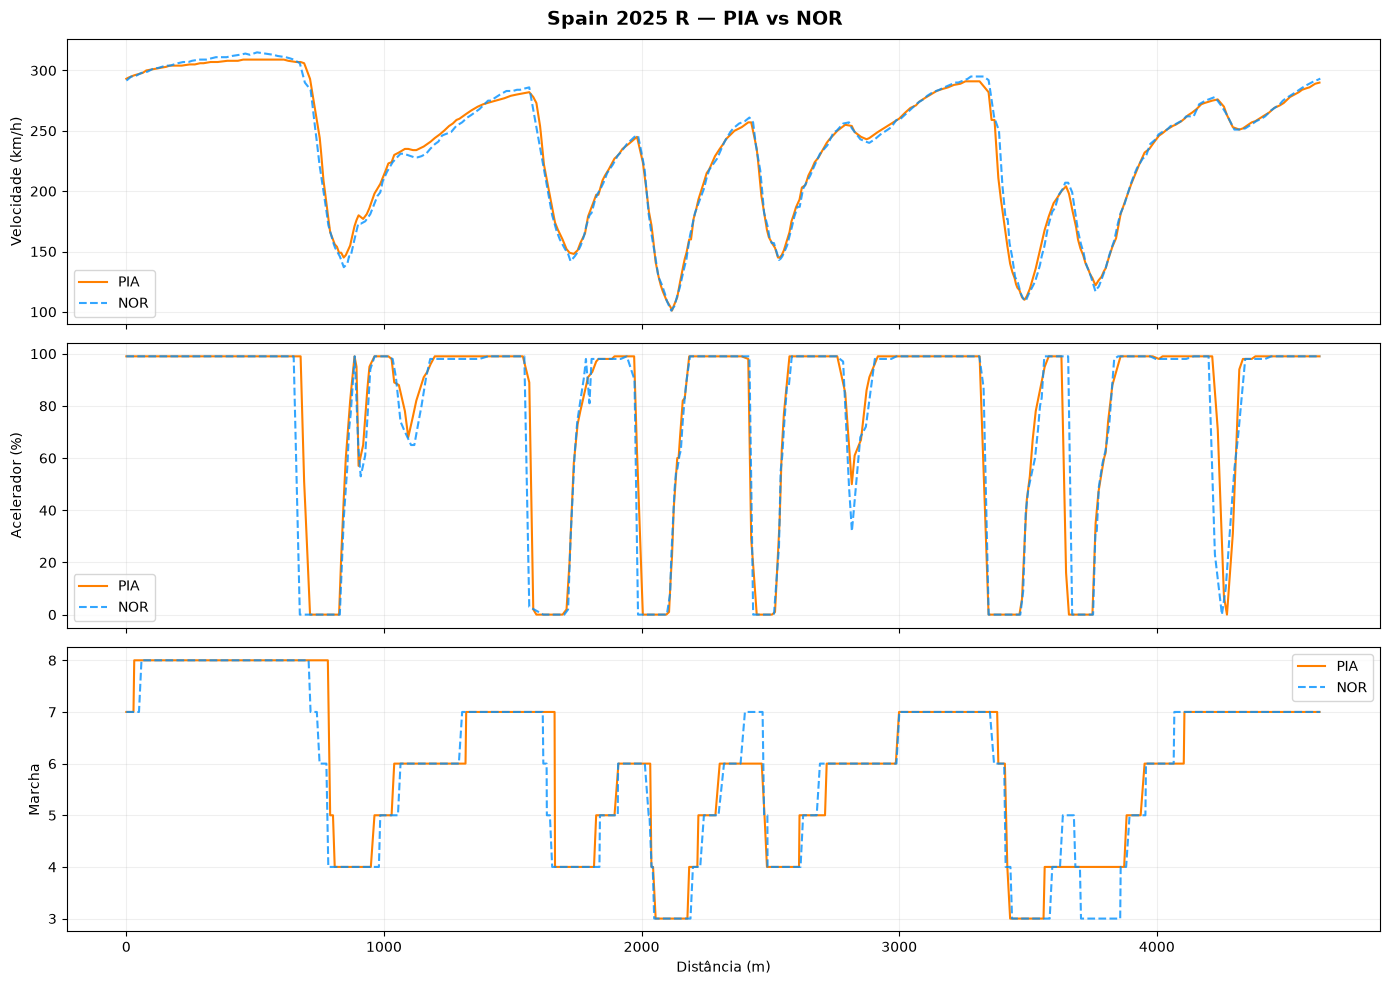

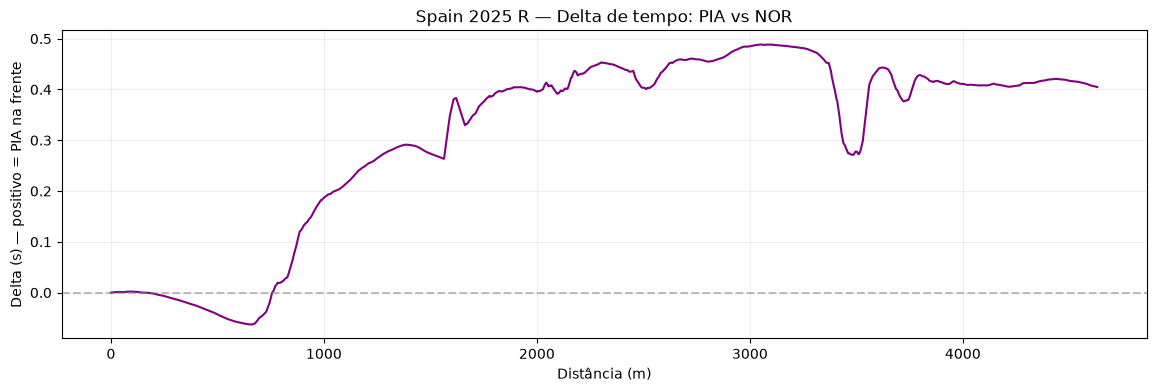

In [14]:
tel_pia, tel_nor = comparar_pilotos(2025, 'Spain', 'R', 'PIA', 'NOR')

# Estudando um ponto interessante com uma grande troca de vantagem

In [15]:
def encontrar_ponto_na_pista(telemetria, distancia_alvo):
    """
    Recebe a telemetria de uma volta e uma distância (em metros),
    e retorna as coordenadas X, Y do ponto mais próximo dessa distância.
    """
    idx = (telemetria['Distance'] - distancia_alvo).abs().idxmin()
    x = telemetria.loc[idx, 'X']
    y = telemetria.loc[idx, 'Y']
    return x, y

In [16]:
x_evento, y_evento = encontrar_ponto_na_pista(tel_pia, 3400)
print(f"Ponto em X={x_evento:.0f}, Y={y_evento:.0f}")

Ponto em X=1165, Y=1751


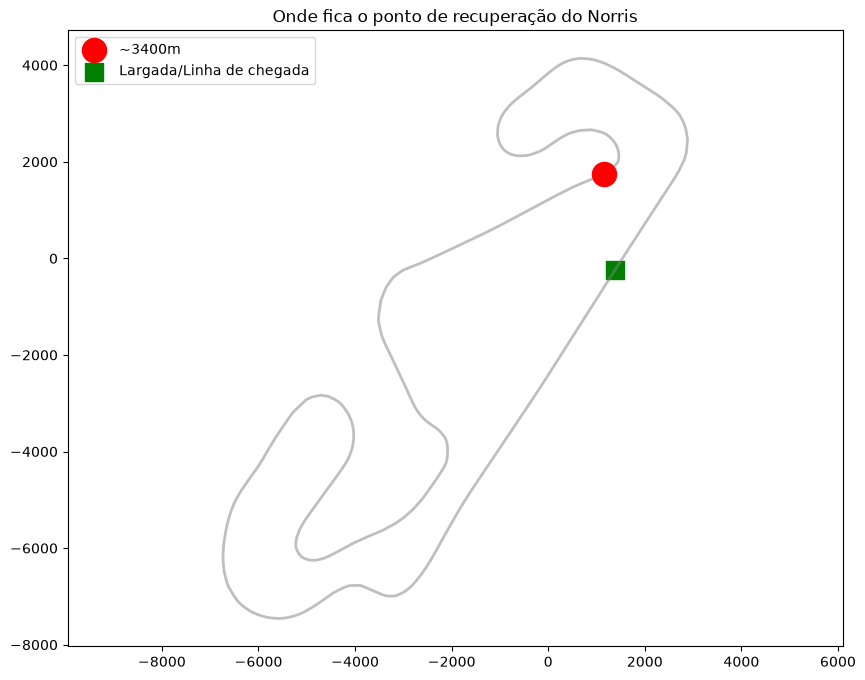

In [17]:
plt.figure(figsize=(10, 8))
plt.plot(tel_pia['X'], tel_pia['Y'], color='gray', linewidth=2, alpha=0.5)
plt.scatter(x_evento, y_evento, color='red', s=300, zorder=5, label='~3400m')
plt.scatter(tel_pia['X'].iloc[0], tel_pia['Y'].iloc[0], color='green', s=150, marker='s', label='Largada/Linha de chegada')

plt.title('Onde fica o ponto de recuperação do Norris')
plt.legend()
plt.axis('equal')
plt.show()

# A partir daqui estamos "automatizando" essa comparação com o delta de tempo. Comparando com mais pilotos agora

core           INFO 	Loading data for Spanish Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '4', '1', '63', '44', '12', '16', '10', '6', '14', '23', '5', '30', '18', '87', '27', '31', '55', '43', '22']
c:\Users\joaom\telemetria-f1\.venv\Lib\site-packages\fastf1\core.py:3175: FutureWarning: pick_driver is depre

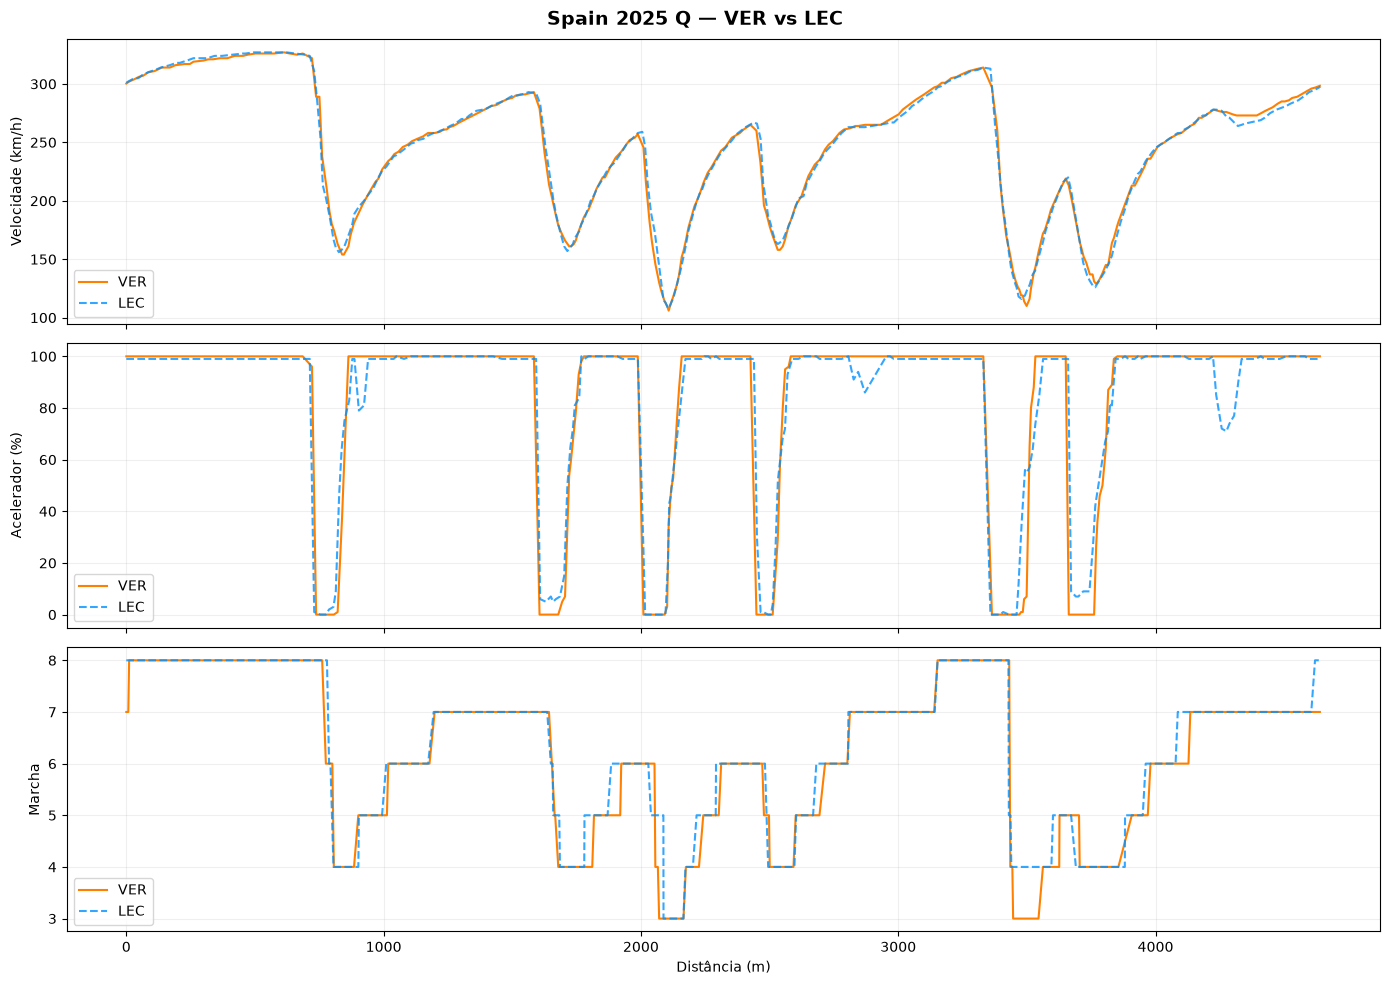

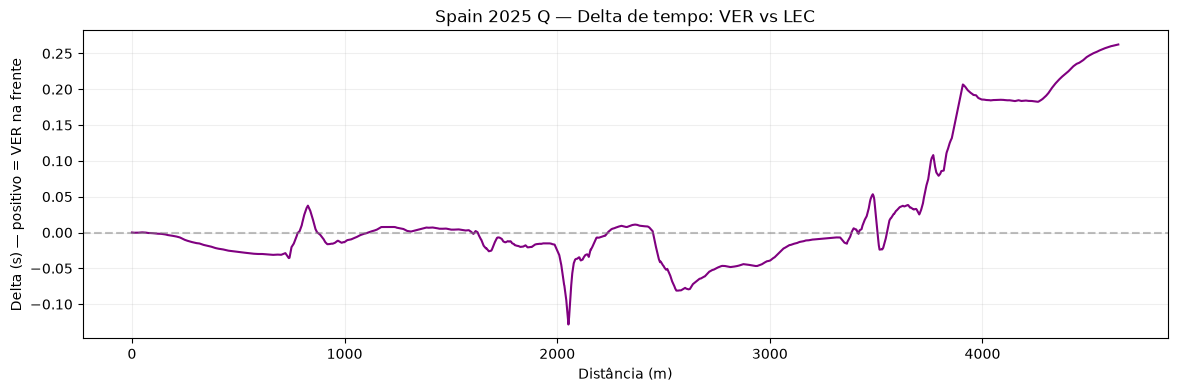

In [18]:
tel_ver, tel_lec = comparar_pilotos(2025, 'Spain', 'Q', 'VER', 'LEC')

# Abaixo um gráfico que mostra a distribuição da velocidade do piloto em toda a pista. Mostrando os trechos com suas velocidades, é bem intuitivo e prático

In [19]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

def mapa_velocidade(telemetria, titulo='Mapa de velocidade'):
    """
    Plota o traçado da pista colorido pela velocidade em cada ponto.
    """
    x = telemetria['X'].values
    y = telemetria['Y'].values
    speed = telemetria['Speed'].values
    
    # Cria pares de pontos consecutivos (segmentos de linha)
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    norm = Normalize(vmin=speed.min(), vmax=speed.max())
    lc = LineCollection(segments, cmap='plasma', norm=norm)
    lc.set_array(speed)
    lc.set_linewidth(4)
    
    line = ax.add_collection(lc)
    ax.set_xlim(x.min() - 200, x.max() + 200)
    ax.set_ylim(y.min() - 200, y.max() + 200)
    ax.axis('equal')
    ax.axis('off')  # remove os eixos, fica mais limpo visualmente
    ax.set_title(titulo)
    
    cbar = fig.colorbar(line, ax=ax)
    cbar.set_label('Velocidade (km/h)')
    
    plt.show()

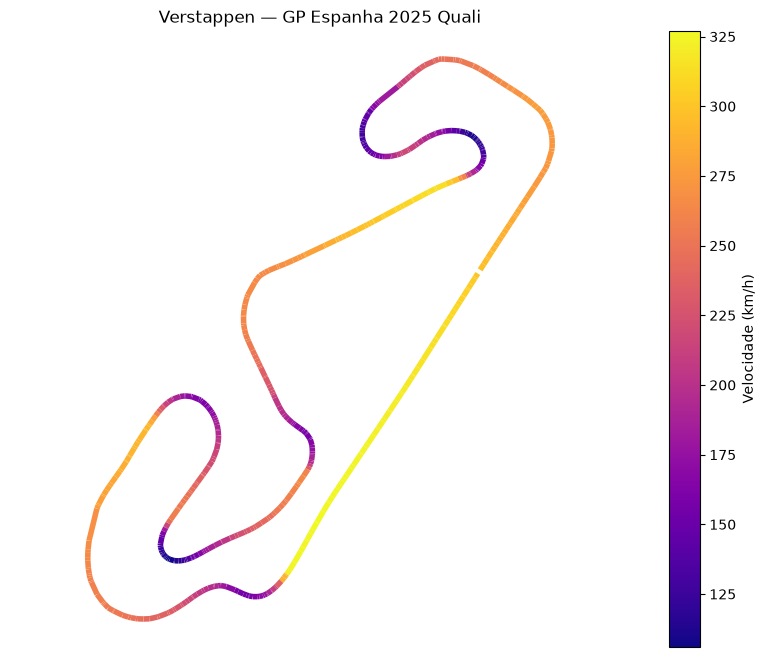

In [20]:
mapa_velocidade(tel_ver, titulo='Verstappen — GP Espanha 2025 Quali')

# Agora comparando...

In [21]:
def comparar_mapas_velocidade(tel1, tel2, nome1, nome2, titulo_geral=''):
    """
    Plota dois mapas de velocidade lado a lado, na mesma escala de cor,
    pra comparação direta entre dois pilotos.
    """
    # Pega o min/max de velocidade considerando os DOIS pilotos juntos
    # (importante pra escala de cor ser igual nos dois gráficos)
    speed_min = min(tel1['Speed'].min(), tel2['Speed'].min())
    speed_max = max(tel1['Speed'].max(), tel2['Speed'].max())
    norm = Normalize(vmin=speed_min, vmax=speed_max)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    for ax, tel, nome in zip(axes, [tel1, tel2], [nome1, nome2]):
        x = tel['X'].values
        y = tel['Y'].values
        speed = tel['Speed'].values
        
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        
        lc = LineCollection(segments, cmap='plasma', norm=norm)
        lc.set_array(speed)
        lc.set_linewidth(4)
        
        ax.add_collection(lc)
        ax.set_xlim(x.min() - 200, x.max() + 200)
        ax.set_ylim(y.min() - 200, y.max() + 200)
        ax.axis('equal')
        ax.axis('off')
        ax.set_title(nome)
    
    fig.suptitle(titulo_geral, fontsize=14, fontweight='bold')
    
    # Uma única barra de cor compartilhada pelos dois gráficos
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='plasma'), ax=axes, fraction=0.03)
    cbar.set_label('Velocidade (km/h)')
    
    plt.show()

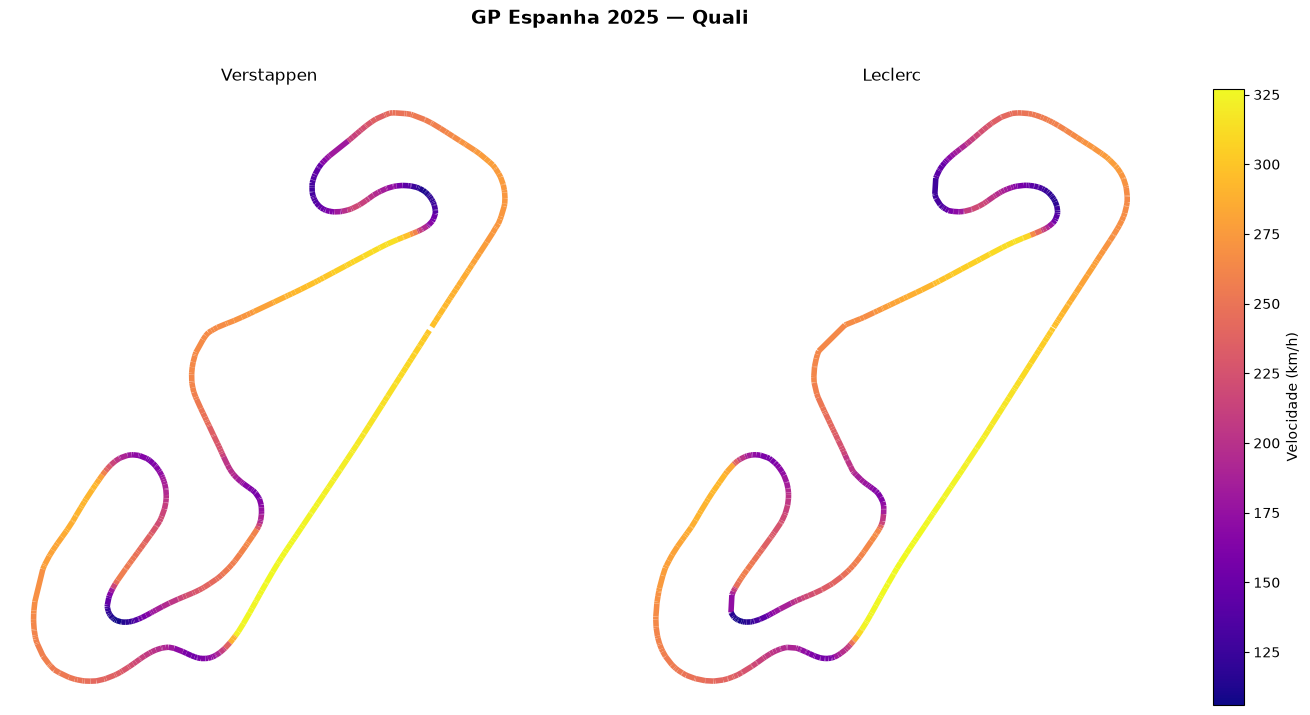

In [22]:
comparar_mapas_velocidade(tel_ver, tel_lec, 'Verstappen', 'Leclerc', 
                            titulo_geral='GP Espanha 2025 — Quali')

# Analisaremos agora os instints do GP usado em todo o teste

In [23]:
session_corrida = fastf1.get_session(2025, 'Spain', 'R')
session_corrida.load()

voltas_pia = session_corrida.laps.pick_driver('PIA')

# Mostra só a primeira e última volta de cada stint, pra ver a transição
voltas_pia.groupby('Stint').agg(
    primeira_volta=('LapNumber', 'min'),
    ultima_volta=('LapNumber', 'max'),
    composto=('Compound', 'first')
)

core           INFO 	Loading data for Spanish Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 19 drivers: ['81', '4', '16', '63', '27', '44', '6', '10', '14', '1', '30', '5', '22', '55', '43', '31', '87', '12', '23']
c:\Users\joaom\telemetria-f1\.venv\Lib\site-packages\fastf1\core.py:

,primeira_volta,ultima_volta,composto
Stint,,,
1.0,1.0,22.0,SOFT
2.0,23.0,49.0,MEDIUM
3.0,50.0,55.0,SOFT
4.0,56.0,66.0,SOFT


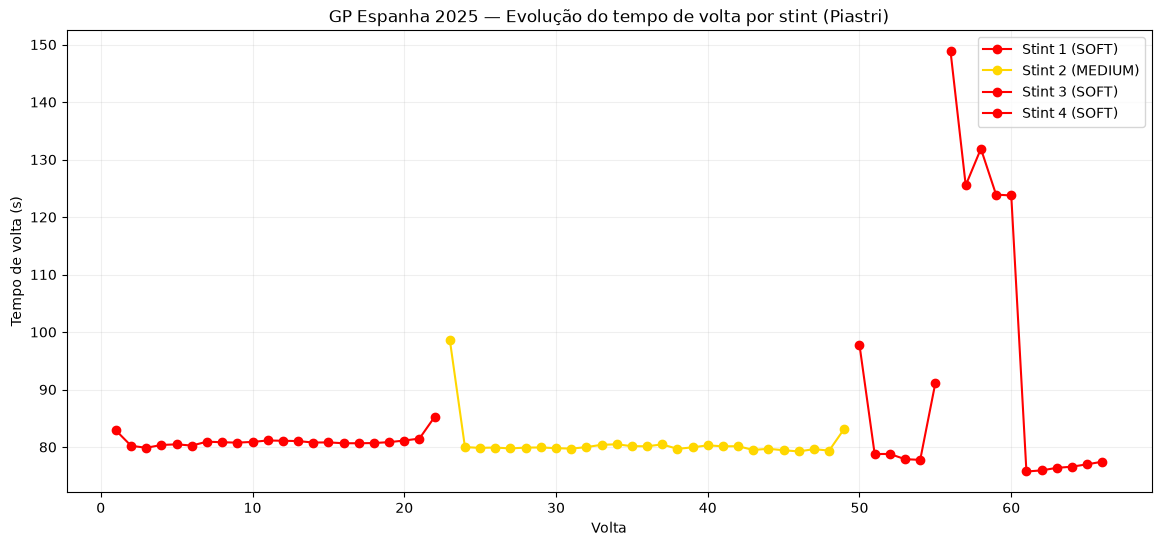

In [24]:
cores_composto = {'SOFT': 'red', 'MEDIUM': 'gold', 'HARD': 'gray', 'INTERMEDIATE': 'green', 'WET': 'blue'}

plt.figure(figsize=(14, 6))

for stint_num in voltas_pia['Stint'].unique():
    stint_data = voltas_pia[voltas_pia['Stint'] == stint_num]
    composto = stint_data['Compound'].iloc[0]
    cor = cores_composto.get(composto, 'black')
    
    plt.plot(stint_data['LapNumber'], stint_data['LapTime'].dt.total_seconds(), 
              marker='o', color=cor, label=f'Stint {int(stint_num)} ({composto})')

plt.xlabel('Volta')
plt.ylabel('Tempo de volta (s)')
plt.title('GP Espanha 2025 — Evolução do tempo de volta por stint (Piastri)')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# Automatizando novamente...

In [25]:
def analisar_stints(ano, gp, piloto):
    """
    Plota a evolução do tempo de volta por stint numa corrida,
    colorido por composto de pneu usado.
    """
    session = fastf1.get_session(ano, gp, 'R')
    session.load()
    
    voltas = session.laps.pick_driver(piloto)
    
    cores_composto = {'SOFT': 'red', 'MEDIUM': 'gold', 'HARD': 'gray', 
                       'INTERMEDIATE': 'green', 'WET': 'blue'}
    
    plt.figure(figsize=(14, 6))
    
    for stint_num in voltas['Stint'].unique():
        stint_data = voltas[voltas['Stint'] == stint_num]
        composto = stint_data['Compound'].iloc[0]
        cor = cores_composto.get(composto, 'black')
        
        plt.plot(stint_data['LapNumber'], stint_data['LapTime'].dt.total_seconds(), 
                  marker='o', color=cor, label=f'Stint {int(stint_num)} ({composto})')
    
    plt.xlabel('Volta')
    plt.ylabel('Tempo de volta (s)')
    plt.title(f'{gp} {ano} — Evolução do tempo de volta por stint ({piloto})')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()
    
    return voltas

core           INFO 	Loading data for Spanish Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 19 drivers: ['81', '4', '16', '63', '27', '44', '6', '10', '14', '1', '30', '5', '22', '55', '43', '31', '87', '12', '23']
c:\Users\joaom\telemetria-f1\.venv\Lib\site-packages\fastf1\core.py:

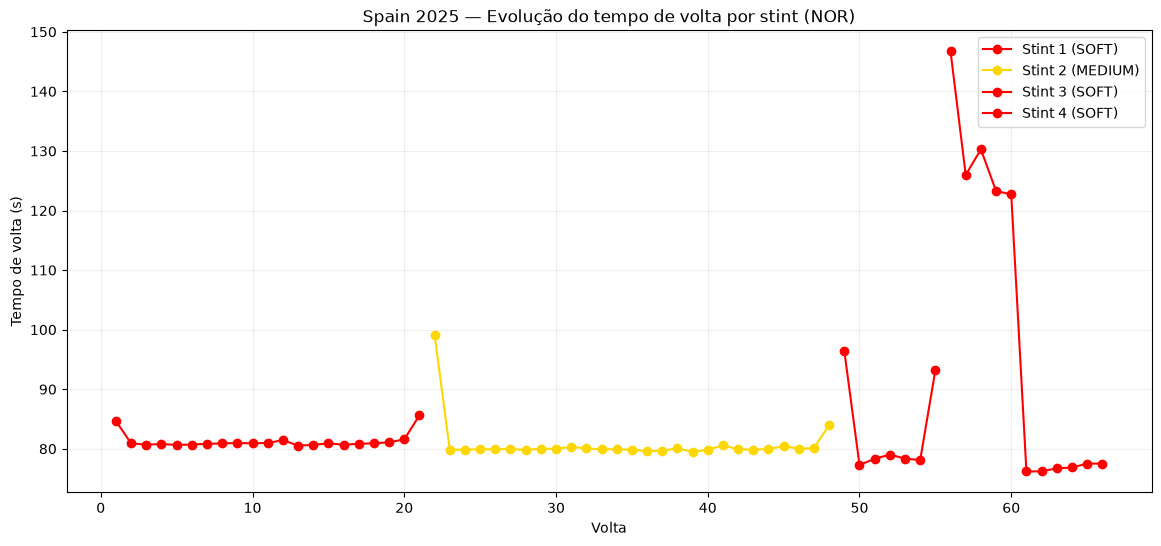

In [26]:
voltas_nor = analisar_stints(2025, 'Spain', 'NOR')

# Iremos comparar os instints de 2 pilotos agora

In [27]:
def obter_dados_corrida(ano, gp, piloto):
    """
    Carrega a corrida e retorna as voltas de um piloto específico,
    sem plotar nada.
    """
    session = fastf1.get_session(ano, gp, 'R')
    session.load()
    voltas = session.laps.pick_driver(piloto)
    return voltas

In [28]:
def comparar_stints(voltas1, voltas2, nome1, nome2, titulo=''):
    """
    Sobrepõe a evolução do tempo de volta de dois pilotos no mesmo gráfico,
    diferenciando por estilo de linha e colorindo por composto.
    """
    cores_composto = {'SOFT': 'red', 'MEDIUM': 'gold', 'HARD': 'gray', 
                       'INTERMEDIATE': 'green', 'WET': 'blue'}
    
    plt.figure(figsize=(14, 6))
    
    # Piloto 1 — linha sólida
    for stint_num in voltas1['Stint'].unique():
        stint_data = voltas1[voltas1['Stint'] == stint_num]
        composto = stint_data['Compound'].iloc[0]
        cor = cores_composto.get(composto, 'black')
        plt.plot(stint_data['LapNumber'], stint_data['LapTime'].dt.total_seconds(),
                  marker='o', color=cor, linestyle='-', alpha=0.9,
                  label=f'{nome1} - Stint {int(stint_num)} ({composto})')
    
    # Piloto 2 — linha tracejada
    for stint_num in voltas2['Stint'].unique():
        stint_data = voltas2[voltas2['Stint'] == stint_num]
        composto = stint_data['Compound'].iloc[0]
        cor = cores_composto.get(composto, 'black')
        plt.plot(stint_data['LapNumber'], stint_data['LapTime'].dt.total_seconds(),
                  marker='^', color=cor, linestyle='--', alpha=0.6,
                  label=f'{nome2} - Stint {int(stint_num)} ({composto})')
    
    plt.xlabel('Volta')
    plt.ylabel('Tempo de volta (s)')
    plt.title(titulo)
    plt.legend(fontsize=8, ncol=2)
    plt.grid(alpha=0.2)
    plt.show()

core           INFO 	Loading data for Spanish Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 19 drivers: ['81', '4', '16', '63', '27', '44', '6', '10', '14', '1', '30', '5', '22', '55', '43', '31', '87', '12', '23']
c:\Users\joaom\telemetria-f1\.venv\Lib\site-packages\fastf1\core.py:

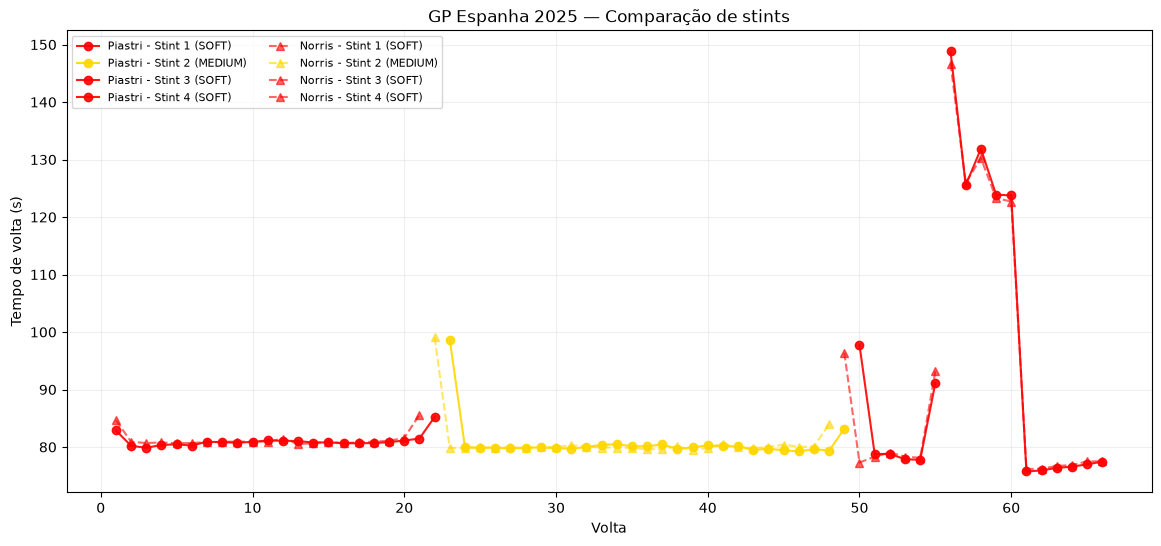

In [29]:
voltas_pia2 = obter_dados_corrida(2025, 'Spain', 'PIA')
voltas_nor2 = obter_dados_corrida(2025, 'Spain', 'NOR')

comparar_stints(voltas_pia2, voltas_nor2, 'Piastri', 'Norris',
                 titulo='GP Espanha 2025 — Comparação de stints')